## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [46]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q --user
#!pip install numpy==2.0.1 pandas==2.2.1 matplotlib==3.8.2 seaborn==0.13.2 scikit-learn==1.4.1.post1 sklearn-pandas==2.2.0
!pip install numpy==1.26.4 pandas==2.2.1 matplotlib==3.8.2 seaborn==0.13.2 scikit-learn==1.4.1.post1 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [47]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Train-test split
from sklearn.model_selection import train_test_split

# Decision Tree model
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [48]:
# Mount Google Drive (only if using Colab)
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
file_path = '/content/drive/MyDrive/AIML-UTA-PY/Loan_Modelling.csv'
df = pd.read_csv(file_path)

# Create a working copy of the data
data = df.copy()

# Display first few rows
data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### **Observation**

1. The dataset contains customer demographic and financial details along with a binary target variable Personal_Loan (0 = No, 1 = Yes).
2. All variables are already in numeric format, so minimal preprocessing is required.
3. ID is just a unique identifier and will not be useful for modelling.
4. ZIPCode represents location information and may not add meaningful value as a numeric feature.



## Data Overview

* Observations
* Sanity checks

In [49]:
# Summary statistics
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


### **Observation**

1. The target variable Personal_Loan has a low mean (~0.096), indicating that only about 9–10% of customers accepted the loan, confirming class imbalance.
2. The Experience variable has a negative minimum value (-3), which is not logically valid and will need to be treated during data preprocessing.

In [50]:
print("First 10 Rows:")
data.head(10)

First 10 Rows:


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


### **Observation**
1. Most customers in the initial rows have not accepted the personal loan (value = 0), indicating a likely imbalance in the target variable.
2. There is noticeable variation in financial attributes such as Income, CCAvg, and Mortgage, suggesting diverse customer financial profiles.

In [51]:
print("Last 5 Rows:")
data.tail(10)

Last 5 Rows:


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4990,4991,55,25,58,95023,4,2.00,3,219,0,0,0,0,1
4991,4992,51,25,92,91330,1,1.90,2,100,0,0,0,0,1
4992,4993,30,5,13,90037,4,0.50,3,0,0,0,0,0,0
4993,4994,45,21,218,91801,2,6.67,1,0,0,0,0,1,0
4994,4995,64,40,75,94588,3,2.00,3,0,0,0,0,1,0
4995,4996,29,3,40,92697,1,1.90,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.40,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.30,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.50,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.80,1,0,0,0,0,1,1


### **Observation**
1. The last rows also show that most customers have not accepted the personal loan, reinforcing the class imbalance in the dataset.
2. Customer attributes such as Income, Mortgage, and CCAvg continue to vary significantly, indicating diverse financial profiles across the dataset.

In [52]:
# Number of rows and columns in the data using the shape attribute of the DataFrame.
rows, columns = data.shape


print(f'Number of Rows: {rows}')
print(f'Number of Columns: {columns}')

Number of Rows: 5000
Number of Columns: 14


### **Observation**
1. The dataset contains 5000 records and 14 features, which is sufficient for building a reliable machine learning model.
2. The number of features is manageable, allowing for easier interpretation and model building without high dimensional complexity.

In [53]:
# Check for missing values
missing_values = data.isnull().sum()

print("Missing values in each column:\n")
print(missing_values)

# Check if any missing values exist
if missing_values.sum() == 0:
    print("\nNo missing values found in the dataset.")
else:
    print("\nMissing values are present in the dataset.")

Missing values in each column:

ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

No missing values found in the dataset.


### **Observation**
1. No missing values are present in any of the columns, so no data imputation is required before model building.

In [54]:
# Drop ID column (not useful for modelling)
data = data.drop('ID', axis=1)

# Check updated data
data.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### **Observation**
1. The dataset now excludes the ID column and contains only relevant features for analysis and modelling.
2. All remaining variables represent meaningful customer attributes, including demographic, financial, and account-related information.

In [55]:
# Create mortgage range categories
bins = [0, 20, 50, 100, 500, float('inf')]
labels = ['0-20K', '20-50K', '50-100K', '100-500K', '500K+']

data['Mortgage_Range'] = pd.cut(data['Mortgage'], bins=bins, labels=labels)

# Check distribution
print("Mortgage range distribution:\n")
print(data['Mortgage_Range'].value_counts().sort_index())

Mortgage range distribution:

Mortgage_Range
0-20K          0
20-50K         0
50-100K      282
100-500K    1231
500K+         25
Name: count, dtype: int64


### **Observation**
1. Most customers fall in the 100K–500K mortgage range, indicating a significant portion have moderate to high mortgage values.
2. Very few customers are in the highest mortgage range (500K+), and some lower ranges have little or no representation.

In [56]:
# Map education codes to meaningful labels
education_map = {
    1: 'Undergrad',
    2: 'Graduate',
    3: 'Advanced/Professional'
}

data['Education_Label'] = data['Education'].map(education_map)

# Check distribution of education levels
education_distribution = data['Education_Label'].value_counts()

print("Distribution of Education Levels:\n")
print(education_distribution)

Distribution of Education Levels:

Education_Label
Undergrad                2096
Advanced/Professional    1501
Graduate                 1403
Name: count, dtype: int64


### **Observation**
1. Undergraduate customers form the largest group, followed by advanced/professional and graduate customers.
2. The dataset has a fairly balanced distribution across education levels, which is useful for analysing its impact on loan acceptance.

In [57]:

# Check the relationship between Education and Personal Loan
education_loan_crosstab = pd.crosstab(data['Education_Label'], data['Personal_Loan'])

print("Cross-tabulation of Education Level and Personal Loan:\n")
print(education_loan_crosstab)

Cross-tabulation of Education Level and Personal Loan:

Personal_Loan             0    1
Education_Label                 
Advanced/Professional  1296  205
Graduate               1221  182
Undergrad              2003   93


### **Observation**
1. Customers with advanced/professional and graduate education levels have a higher number of loan acceptances compared to undergraduates.
2. Undergraduates form the largest group but have relatively fewer loan acceptances, suggesting lower conversion rates in this segment.

In [58]:
# Check correlation between Mortgage and Income
corr_value = data[['Mortgage', 'Income']].corr().iloc[0, 1]

print("Correlation between Mortgage and Income:", round(corr_value, 3))

Correlation between Mortgage and Income: 0.207


### **Observation**
1. There is a weak positive correlation (~0.21) between income and mortgage, indicating that customers with higher income tend to have slightly higher mortgage values.
2. The relationship is not strong, so mortgage cannot be explained by income alone and may depend on other factors

### **Data Quality Observation**

1. The dataset has 5000 records and 14 columns, covering customer demographics, financial details, and account-related information.
2. There are no missing values in the dataset, so no additional data cleaning is required for handling nulls.
3. Most columns are in integer format, while CCAvg is in float, which is expected as it represents average spending.

### **Mortgage Distribution Observations**

1. A large number of customers fall in the lower mortgage range (0–20K), indicating many customers have little or no mortgage.
2. Customers are also spread across higher ranges like 50K–100K and 100K–500K, showing variation in mortgage values.
3. Only a small number of customers have very high mortgages (above 500K).

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

**Question**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

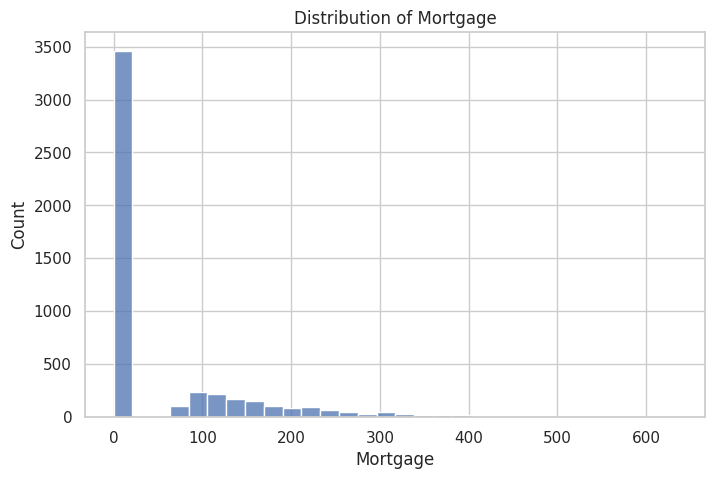

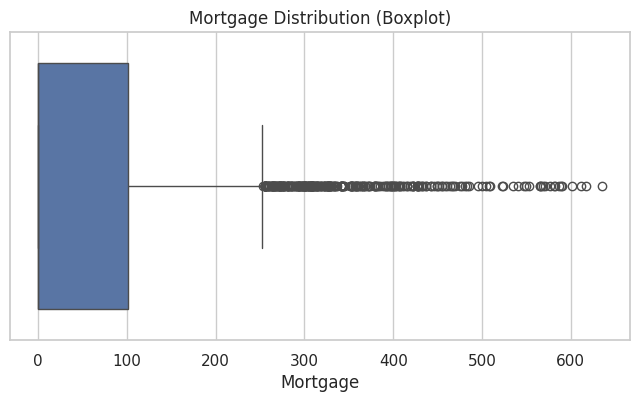

In [59]:
# Histogram to see distribution
plt.figure(figsize=(8,5))
sns.histplot(data['Mortgage'], bins=30)
plt.title('Distribution of Mortgage')
plt.xlabel('Mortgage')
plt.ylabel('Count')
plt.show()

# Boxplot to check outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=data['Mortgage'])
plt.title('Mortgage Distribution (Boxplot)')
plt.show()

### **Observation**
1. The mortgage distribution is highly skewed, with most customers having zero or very low mortgage values.
2. The boxplot shows several high-value outliers, indicating that a small number of customers have significantly large mortgages.
3. Overall, the data suggests that while most customers have minimal mortgage exposure, a few customers hold much higher mortgage amounts.

In [60]:
# Number of customers with no mortgage.
no_mortgage_count = data[data['Mortgage'] == 0].shape[0]

# Total number of customers.
total_customers = data.shape[0]

# Percentage of customers with no mortgage.
percentage_no_mortgage = (no_mortgage_count / total_customers) * 100

print(f"Number of customers with no mortgage: {no_mortgage_count:,}")
print(f"Total number of customers: {total_customers:,}")
print(f'Percentage of customers with no mortgage: {percentage_no_mortgage:.2f}%')

Number of customers with no mortgage: 3,462
Total number of customers: 5,000
Percentage of customers with no mortgage: 69.24%


### **Observation**
1. Around 69% of customers do not have a mortgage, showing that a majority of customers have no housing loan commitments.
2. This confirms the earlier distribution, where most mortgage values were concentrated at zero or very low levels..

### **Distribution of Mortgage**
1. The mortgage distribution is highly skewed, with most customers having zero or very low mortgage values.
2. Around 69% of customers (3462 out of 5000) do not have any mortgage.
3. A small number of customers have very high mortgage values, which appear as outliers.
### **Recommendation**
1. Since a large proportion of customers do not have a mortgage, the bank can target this segment with mortgage-related pro

**Question**:

2. How many customers have credit cards?

Credit Card Ownership Counts:

CreditCard
0    3530
1    1470
Name: count, dtype: int64

Credit Card Ownership Percentage (%):

CreditCard
0    70.6
1    29.4
Name: count, dtype: float64


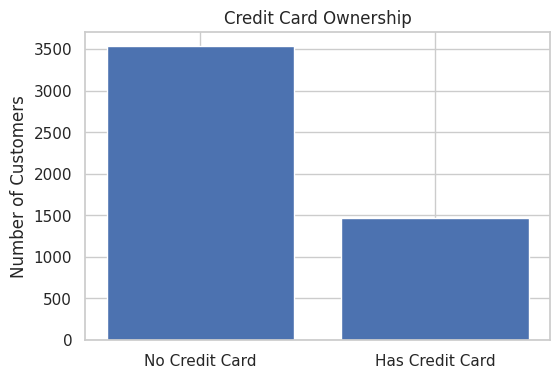

In [61]:
# Count of customers with and without credit cards
cc_counts = data['CreditCard'].value_counts().sort_index()

print("Credit Card Ownership Counts:\n")
print(cc_counts)

# Percentage calculation
cc_percent = (cc_counts / len(data)) * 100

print("\nCredit Card Ownership Percentage (%):\n")
print(cc_percent.round(2))

# Bar plot
plt.figure(figsize=(6,4))
plt.bar(['No Credit Card', 'Has Credit Card'], cc_counts)
plt.title('Credit Card Ownership')
plt.ylabel('Number of Customers')
plt.show()

### **Observations**

1. Around 70.6% of customers do not have a credit card, while only 29.4% have one.
2. A majority of customers do not have a credit card, suggesting an opportunity for the bank to expand its credit card customer base.


### Credit Card Ownership

1. Out of 5,000 customers, 1,470 (29.4%) have credit cards, while 3,530 (70.6%) do not.  

2. A majority of customers do not have a credit card, indicating an opportunity to expand credit card offerings.  

3. This shows that credit card usage is not very high among the customer base.

**Question**:

3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

Correlation with Personal_Loan:

Income                0.502
CCAvg                 0.367
CD_Account            0.316
Mortgage              0.142
Education             0.137
Family                0.061
Securities_Account    0.022
Age                  -0.008
Experience           -0.007
Online                0.006
ZIPCode              -0.003
CreditCard            0.003
Name: Personal_Loan, dtype: float64


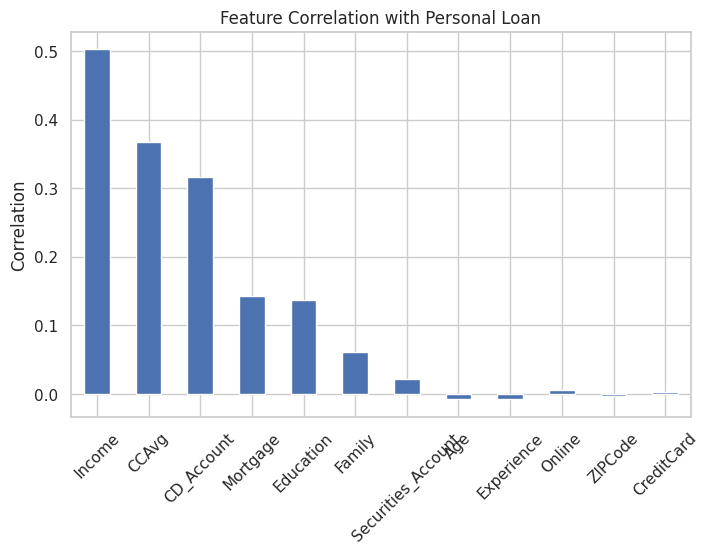

In [62]:
# Select numeric columns
num_data = data.select_dtypes(include='number')

# Correlation matrix
corr_matrix = num_data.corr()

# Correlation with target
target_corr = corr_matrix['Personal_Loan'].drop('Personal_Loan')

# Sort by absolute value
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

print("Correlation with Personal_Loan:\n")
print(target_corr.round(3))

# Plot
plt.figure(figsize=(8,5))
target_corr.plot(kind='bar')
plt.title('Feature Correlation with Personal Loan')
plt.ylabel('Correlation')
plt.xticks(rotation=45)
plt.show()

### **Observations**

- Income shows the strongest positive correlation (~0.50) with Personal_Loan, indicating higher-income customers are more likely to accept the loan.  

- CCAvg (~ 0.37) and CD_Account (~0.32) also show moderate positive relationships, suggesting that financially active customers are more likely to take loans.  

- Mortgage and Education have weak positive correlations (~0.14), indicating a limited influence on loan decisions.  

- Other variables such as Age, Experience, and CreditCard show very weak or no correlation with Personal_Loan.

**Questions:**

4. How does a customer's interest in purchasing a loan vary with their age?

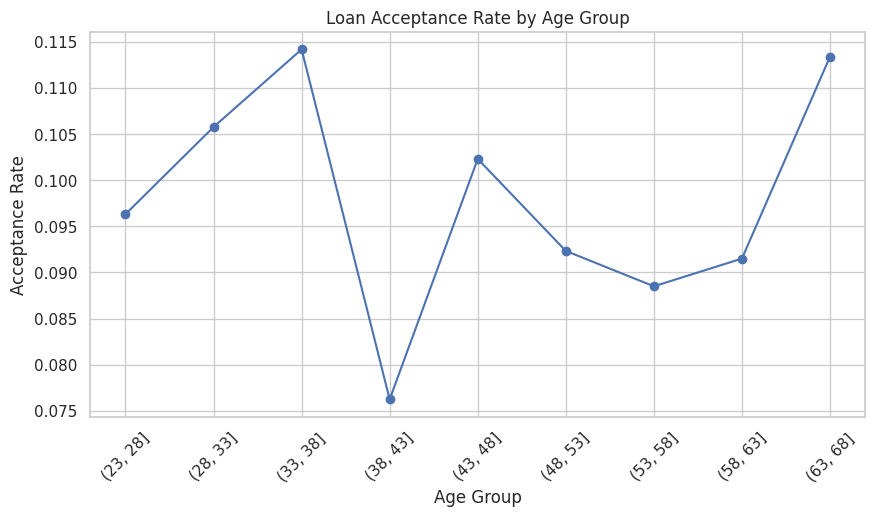

In [63]:
# Create age groups (5-year bins)
age_bins = range(data['Age'].min(), data['Age'].max() + 5, 5)
data['Age_Group'] = pd.cut(data['Age'], bins=age_bins)

# Calculate loan acceptance rate
loan_by_age = data.groupby('Age_Group')['Personal_Loan'].mean()

# Plot
plt.figure(figsize=(10,5))
loan_by_age.plot(marker='o')
plt.title('Loan Acceptance Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### **Observation:** Personal Loan Acceptance by Age

1. Loan acceptance rates vary slightly across age groups, mostly ranging between 7% and 11%.  

2. Some middle and older age groups show slightly higher acceptance rates compared to others.  

3. Overall, there is no clear linear trend, indicating that age is not a strong factor in loan acceptance.

**Question**

5. How does a customer's interest in purchasing a loan vary with their education?

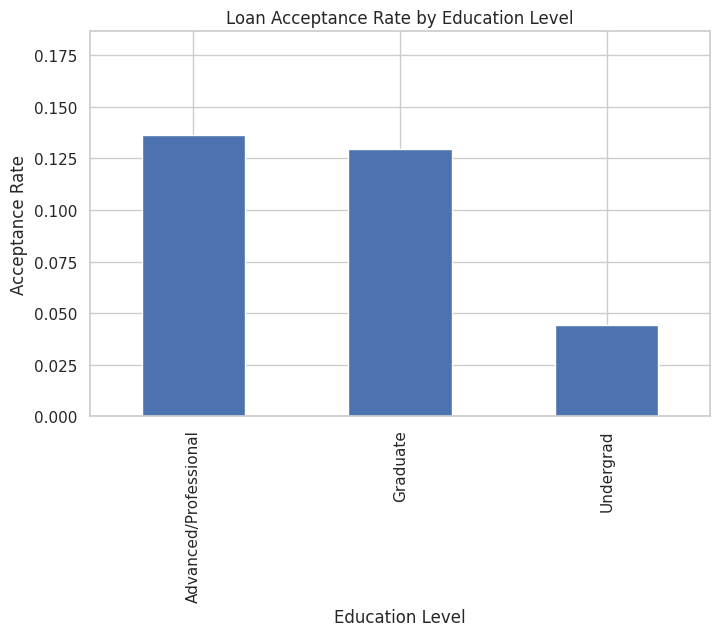

In [64]:
# Loan acceptance rate by education level
loan_by_education = data.groupby('Education_Label')['Personal_Loan'].mean()

# Plot
plt.figure(figsize=(8,5))
loan_by_education.plot(kind='bar')
plt.title('Loan Acceptance Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Acceptance Rate')
plt.ylim(0, loan_by_education.max() + 0.05)
plt.show()

### **Observation**: Personal Loan Acceptance by Education

- Customers with advanced/professional education have the highest loan acceptance rate, followed closely by graduates.  

- Undergraduates have a significantly lower acceptance rate compared to the other groups.  

- This indicates that loan acceptance increases with education level.

### **Summary of Key Observations**

- Mortgage: Around 69% of customers do not have a mortgage, and the distribution is skewed with a few high-value cases.  

- Credit Cards: About 29% of customers have credit cards, indicating relatively low usage among the customer base.  

- Correlation: Income, CCAvg, and CD_Account show stronger relationships with loan acceptance, while other variables have weaker influence.  

- Age: Loan acceptance varies across age groups, but no strong trend is observed.  

- Education: Customers with higher education levels show higher loan acceptance rates.  

- Family Size: Customers with family sizes of 3 or 4 show relatively higher loan uptake.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [65]:
# Drop unnecessary columns
data = data.drop(['ZIPCode', 'Mortgage_Range', 'Age_Group', 'Education_Label'], axis=1, errors='ignore')

# Check missing values
print(data.isnull().sum())

# Fix negative Experience values
exp_median = data[data['Experience'] >= 0]['Experience'].median()
data['Experience'] = data['Experience'].apply(lambda x: exp_median if x < 0 else x)

# Define features and target
X = data.drop('Personal_Loan', axis=1)
y = data['Personal_Loan']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data ready for modeling.")

Age                   0
Experience            0
Income                0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64
Data ready for modeling.


### Data Preprocessing Observations

1. No missing values are present in the dataset after removing unnecessary columns.  
2. Negative values in the Experience column were handled by replacing them with the median value.  
3. ZIPCode and temporary columns created during EDA were removed as they are not useful for modelling.  
4. The dataset is clean and ready for building the decision tree model.

## Model Building

### Model Evaluation Criterion


To evaluate the model performance, the following metrics are considered:

- **Accuracy**: Measures the overall correctness of the model. However, it may not be reliable due to class imbalance.  

- **Precision**: Indicates how many of the predicted loan buyers actually accepted the loan. This helps reduce unnecessary marketing efforts.  

- **Recall**: Shows how many actual loan buyers were correctly identified. This is important to avoid missing potential customers.  

- **F1-Score**: Provides a balance between precision and recall.  

- **ROC-AUC**: Measures how well the model distinguishes between customers who accept and do not accept the loan.  

- **Confusion Matrix**: Helps understand the types of prediction errors made by the model.  

### Key Metric

Recall (along with F1-score) is the most important metric for this problem, as the goal is to identify as many potential loan buyers as possible.


### Model Building

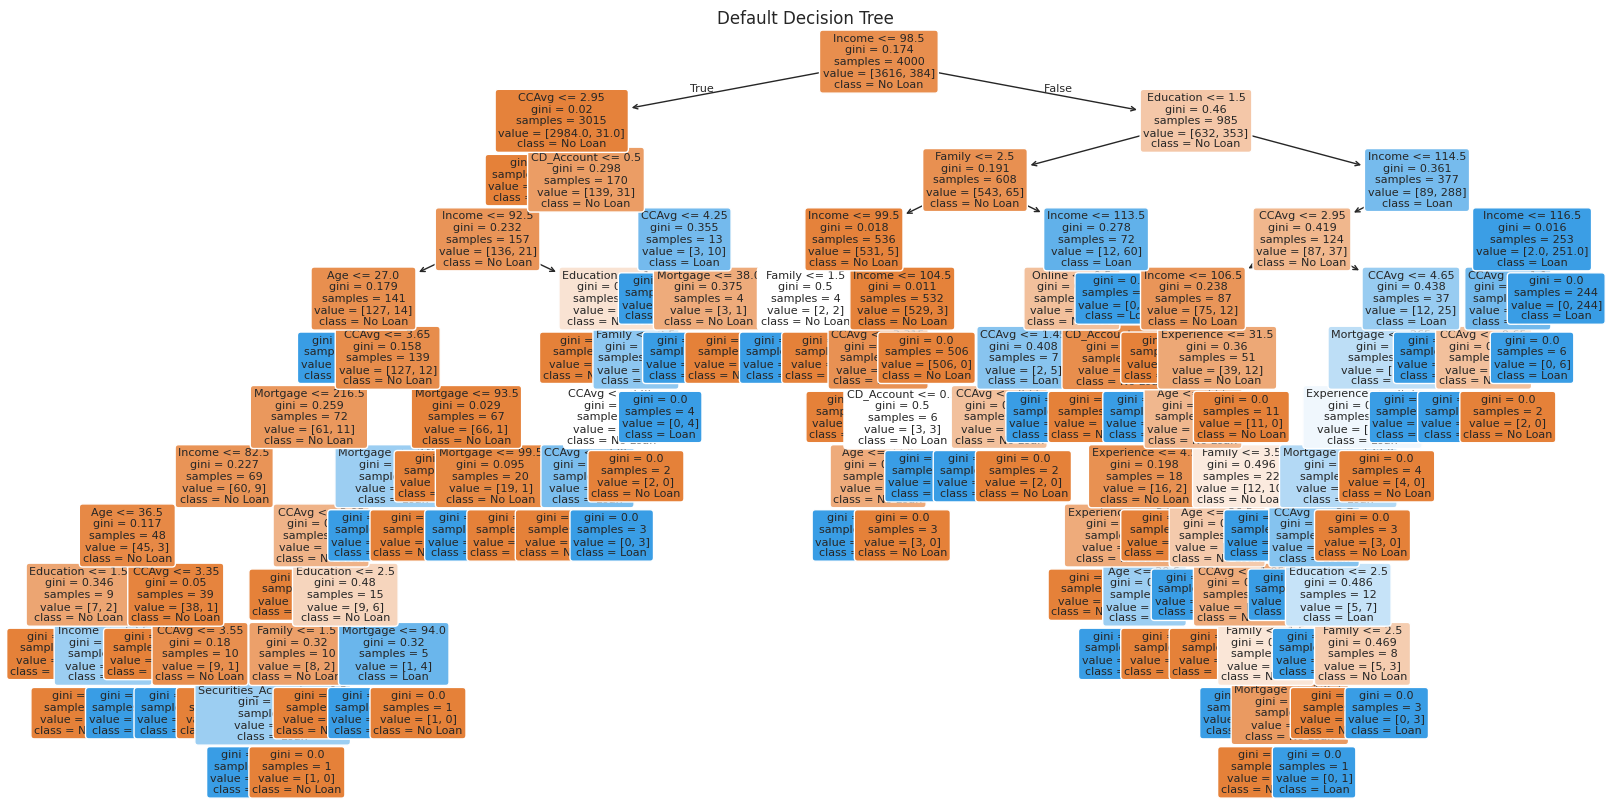

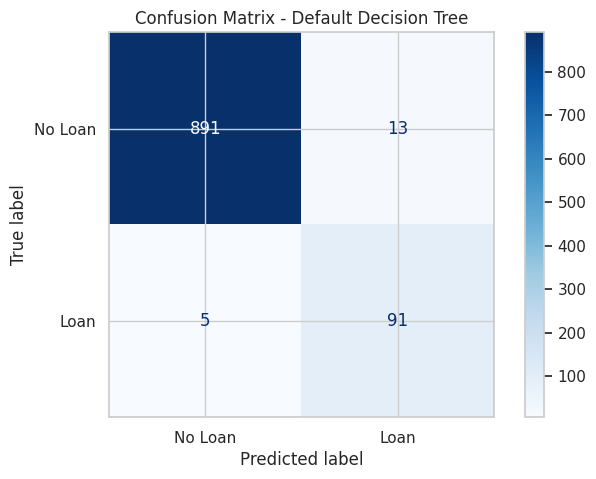

Training Accuracy: 1.0
Testing Accuracy: 0.982
Precision: 0.875
Recall: 0.948
F1 Score: 0.91
ROC-AUC: 0.967


In [66]:
# Build and train the default decision tree model
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

# Predictions
y_train_pred = dtree.predict(X_train)
y_test_pred = dtree.predict(X_test)
y_test_prob = dtree.predict_proba(X_test)[:, 1]

# Plot decision tree
plt.figure(figsize=(20,10))
plot_tree(
    dtree,
    feature_names=X_train.columns,
    class_names=['No Loan', 'Loan'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Default Decision Tree")
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Loan', 'Loan'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Default Decision Tree")
plt.show()


# Model performance
print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred), 3))
print("Testing Accuracy:", round(accuracy_score(y_test, y_test_pred), 3))
print("Precision:", round(precision_score(y_test, y_test_pred), 3))
print("Recall:", round(recall_score(y_test, y_test_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_test_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob), 3))

### Observation: Default Decision Tree Model

- The model performs very well on the test data, correctly predicting most cases as seen in the confusion matrix.  
- The model shows strong predictive performance with minimal false positives and false negatives.
- It accurately identifies a high number of both non-loan and loan customers, with very few misclassifications.  
- However, the decision tree appears highly complex and deep, which may indicate overfitting to the training data.  
- This suggests that although performance is strong, pruning may be required to improve model generalization.




### Observation: Model Performance – Default Decision Tree

- The model achieves very high training accuracy (1.0) and strong test accuracy (0.982), indicating good overall performance.  

- Precision (0.875) and recall (0.948) are both high, showing the model is effective in identifying loan customers while keeping false predictions low.  

- However, the perfect training accuracy compared to slightly lower test accuracy suggests overfitting, where the model has learned the training data too closely.  

- This indicates the need for pruning techniques to simplify the model and improve generalization.

## Model Performance Improvement

## **Pre Prune**

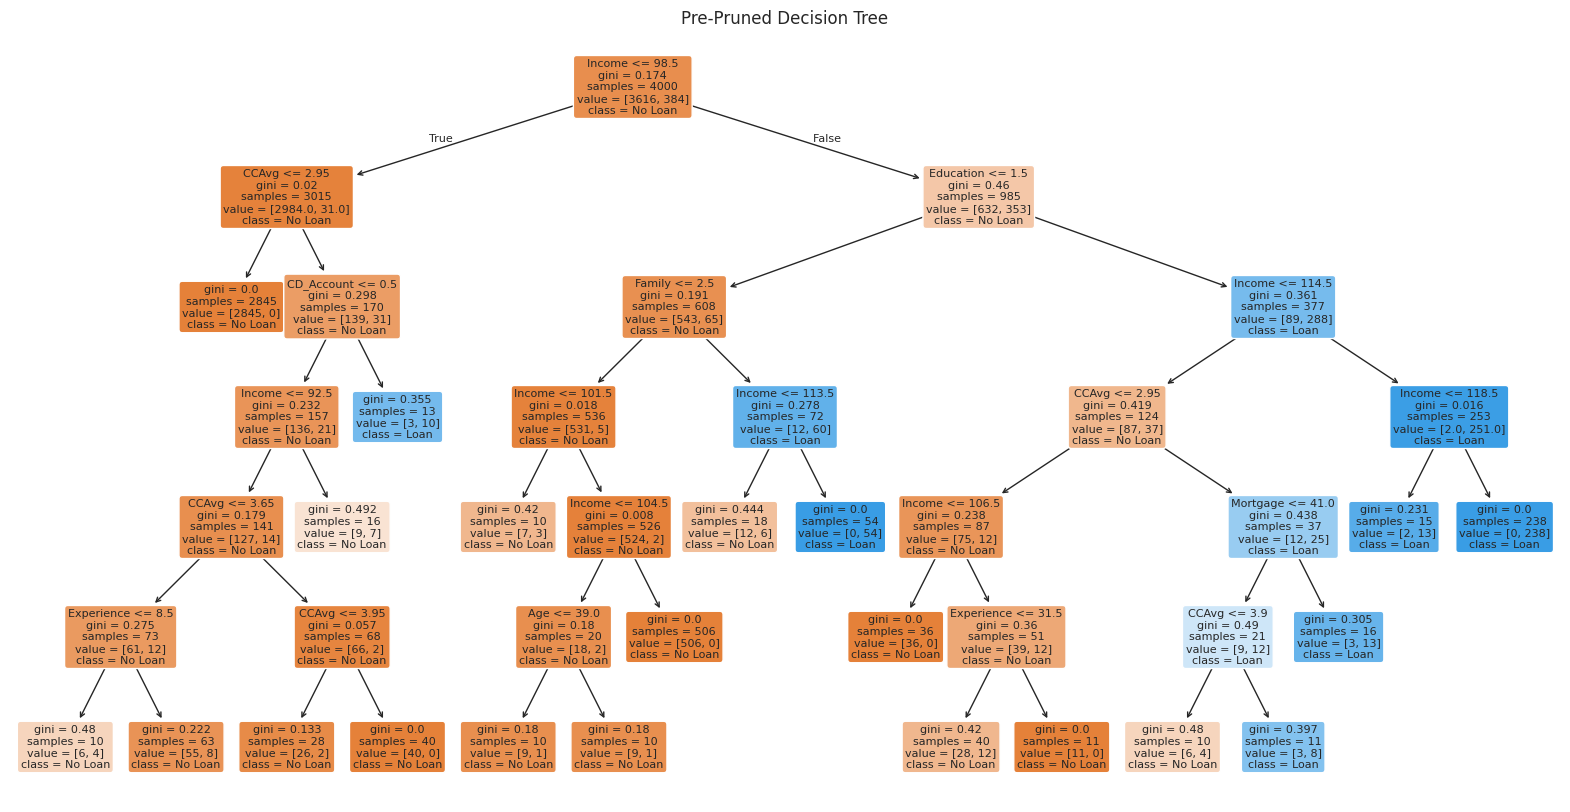

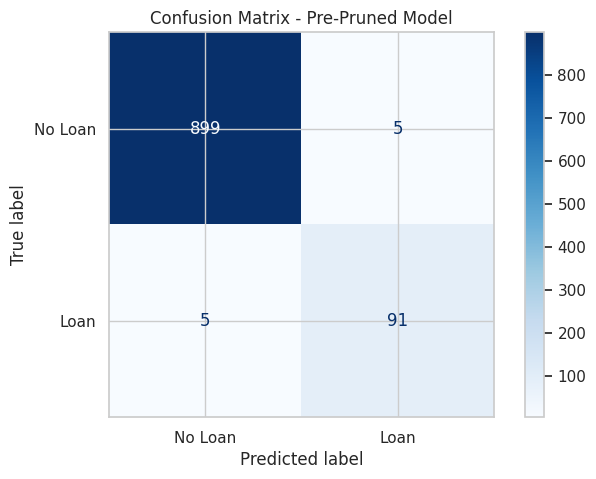

Training Accuracy: 0.985
Testing Accuracy: 0.99
Precision: 0.948
Recall: 0.948
F1 Score: 0.948
ROC-AUC: 0.998


In [67]:
# Pre-pruned decision tree
model_prepruned = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10
)

model_prepruned.fit(X_train, y_train)

# Predictions
y_train_pred_pre = model_prepruned.predict(X_train)
y_test_pred_pre = model_prepruned.predict(X_test)
y_test_prob_pre = model_prepruned.predict_proba(X_test)[:, 1]

# Plot tree
plt.figure(figsize=(20,10))
plot_tree(
    model_prepruned,
    feature_names=X_train.columns,
    class_names=['No Loan', 'Loan'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Pre-Pruned Decision Tree")
plt.show()

# Confusion matrix
cm_pre = confusion_matrix(y_test, y_test_pred_pre)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pre, display_labels=['No Loan', 'Loan'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Pre-Pruned Model")
plt.show()


# Performance Metrix
print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred_pre), 3))
print("Testing Accuracy:", round(accuracy_score(y_test, y_test_pred_pre), 3))
print("Precision:", round(precision_score(y_test, y_test_pred_pre), 3))
print("Recall:", round(recall_score(y_test, y_test_pred_pre), 3))
print("F1 Score:", round(f1_score(y_test, y_test_pred_pre), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob_pre), 3))



### Observation: Pre-Pruned Decision Tree

- The pre-pruned model shows high performance with strong testing accuracy (0.99) and balanced precision and recall (~0.95), indicating effective prediction of both loan and non-loan customers.  

- Compared to the default model, the training accuracy has slightly reduced (from 1.0 to 0.985), suggesting that overfitting has been reduced.  

- The confusion matrix shows very few misclassifications, with the model correctly identifying most customers in both classes.  

- The decision tree is simpler and more interpretable due to pruning constraints, while still maintaining excellent performance.  

- Overall, pre-pruning improves model generalization without significantly impacting accuracy.

## Post Prune

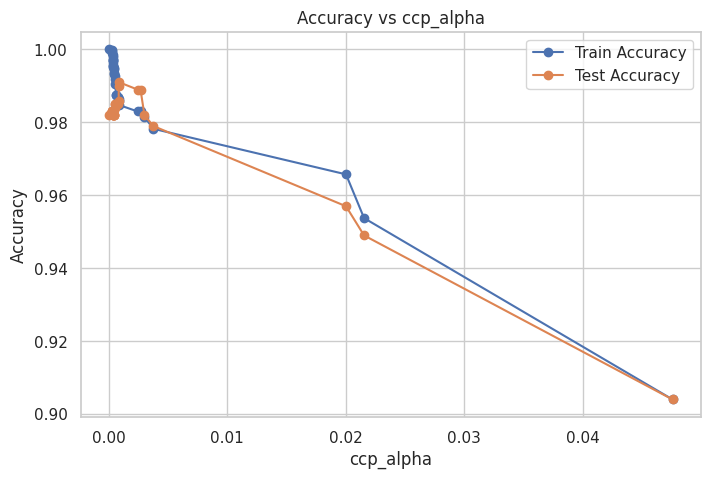

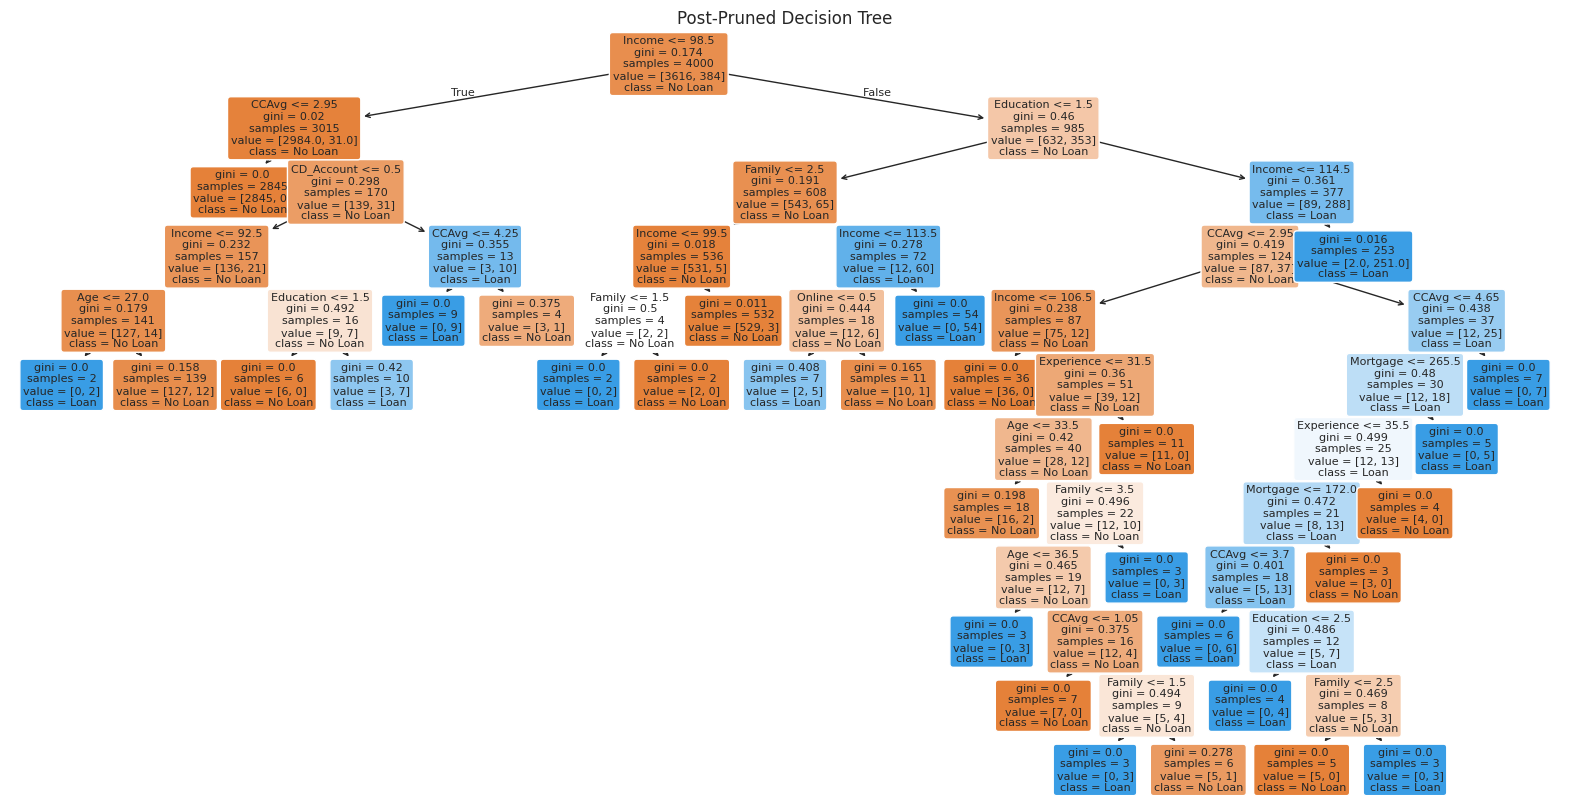

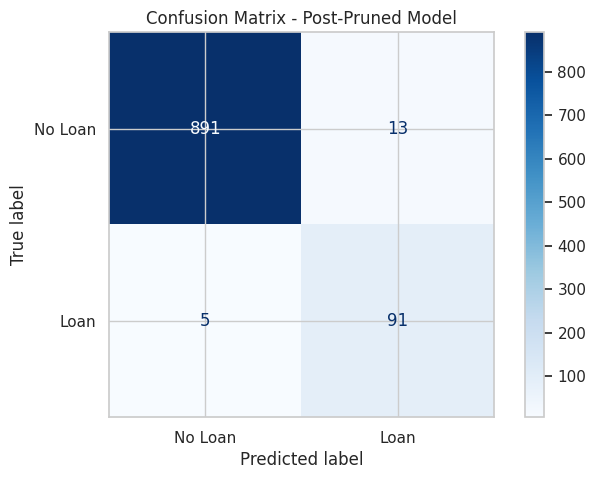

Training Accuracy: 0.993
Testing Accuracy: 0.982
Precision: 0.875
Recall: 0.948
F1 Score: 0.91
ROC-AUC: 0.987


In [68]:
# Rebuild the default decision tree model
model_default = DecisionTreeClassifier(random_state=42)
model_default.fit(X_train, y_train)

# Get cost complexity pruning path
path = model_default.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Check train and test accuracy for different alpha values
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

# Plot alpha vs accuracy
plt.figure(figsize=(8,5))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test Accuracy')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs ccp_alpha')
plt.legend()
plt.show()

# Choose an alpha value
alpha_to_use = ccp_alphas[len(ccp_alphas) // 2]

# Train post-pruned decision tree
model_postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_to_use)
model_postpruned.fit(X_train, y_train)

# Predictions
y_train_pred_post = model_postpruned.predict(X_train)
y_test_pred_post = model_postpruned.predict(X_test)
y_test_prob_post = model_postpruned.predict_proba(X_test)[:, 1]

# Plot post-pruned tree
plt.figure(figsize=(20,10))
plot_tree(
    model_postpruned,
    feature_names=X_train.columns,
    class_names=['No Loan', 'Loan'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Post-Pruned Decision Tree")
plt.show()

# Confusion matrix
cm_post = confusion_matrix(y_test, y_test_pred_post)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_post, display_labels=['No Loan', 'Loan'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Post-Pruned Model")
plt.show()

# Performance metrics
print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred_post), 3))
print("Testing Accuracy:", round(accuracy_score(y_test, y_test_pred_post), 3))
print("Precision:", round(precision_score(y_test, y_test_pred_post), 3))
print("Recall:", round(recall_score(y_test, y_test_pred_post), 3))
print("F1 Score:", round(f1_score(y_test, y_test_pred_post), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob_post), 3))

### Observation: Post-Pruned Decision Tree

- The post-pruned model reduces tree complexity by removing less important branches, resulting in a simpler structure compared to the default model.  

- The training accuracy (0.993) is slightly lower than the default model, indicating reduced overfitting.  

- The testing accuracy (0.982) and other metrics such as precision (0.875) and recall (0.948) remain strong, showing that performance is maintained.  

- Compared to the pre-pruned model, the performance is slightly lower, but the model is simpler and easier to interpret.  

- Overall, post-pruning helps achieve a balance between model complexity and generalization.

## Model Performance Comparison and Final Model Selection

In [69]:
# Metrics for Default Model
metrics_default = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_prob)
}

# Metrics for Pre-Pruned Model
metrics_prepruned = {
    'Accuracy': accuracy_score(y_test, y_test_pred_pre),
    'Precision': precision_score(y_test, y_test_pred_pre),
    'Recall': recall_score(y_test, y_test_pred_pre),
    'F1-Score': f1_score(y_test, y_test_pred_pre),
    'ROC-AUC': roc_auc_score(y_test, y_test_prob_pre)
}

# Metrics for Post-Pruned Model
metrics_postpruned = {
    'Accuracy': accuracy_score(y_test, y_test_pred_post),
    'Precision': precision_score(y_test, y_test_pred_post),
    'Recall': recall_score(y_test, y_test_pred_post),
    'F1-Score': f1_score(y_test, y_test_pred_post),
    'ROC-AUC': roc_auc_score(y_test, y_test_prob_post)
}

# Create comparison table
df_comparison = pd.DataFrame({
    'Default Model (Decision Tree)': pd.Series(metrics_default),
    'Pre-Pruned Model (Decision Tree)': pd.Series(metrics_prepruned),
    'Post-Pruned Model (Decision Tree)': pd.Series(metrics_postpruned)
})

print("Model Performance Comparison:\n")
display(df_comparison.round(3))

Model Performance Comparison:



,Default Model (Decision Tree),Pre-Pruned Model (Decision Tree),Post-Pruned Model (Decision Tree)
Accuracy,0.982,0.990,0.982
Precision,0.875,0.948,0.875
Recall,0.948,0.948,0.948
F1-Score,0.910,0.948,0.910
ROC-AUC,0.967,0.998,0.987


### Model Performance Comparison

- The pre-pruned model achieves the best overall performance, with the highest accuracy (0.99), precision (0.948), and F1-score (0.948).  

- The default and post-pruned models show similar performance, with slightly lower precision (0.875) and F1-score (0.91) compared to the pre-pruned model.

- Recall remains consistently high (0.948) across all models, indicating all models are effective at identifying loan customers.  

- The pre-pruned model also has the highest ROC-AUC (0.998), showing superior ability to distinguish between loan and non-loan customers.  

- Overall, the pre-pruned model provides the best balance between performance and generalization.

### Final Model Selection

- The pre-pruned decision tree is selected as the final model.  

- It outperforms both the default and post-pruned models across most evaluation metrics.  

- The model achieves high accuracy while maintaining strong precision and recall, making it suitable for identifying potential loan customers.  

- Additionally, it reduces overfitting and keeps the model reasonably simple and interpretable.

## Actionable Insights and Business Recommendations


Actionable Insights and Recommendations

- **Use the pre-pruned decision tree for targeting**: This model provides the best balance between accuracy and simplicity, making it suitable for identifying high-potential loan customers.  

- **Focus on high-income and high-spending customers**: Customers with higher income and higher credit card spending (CCAvg) are more likely to accept personal loans.  

- **Target customers with existing CD accounts**: These customers show a higher likelihood of loan acceptance and can be prioritized in campaigns.  

- **Prioritize educated customer segments**: Customers with graduate and advanced education levels have higher conversion rates and should be targeted with tailored offers.  

- **Improve marketing efficiency**: Since the model has high precision (~95%), marketing efforts can be focused on customers with a higher probability of conversion, reducing unnecessary outreach.  

- **Adopt data-driven campaigns**: Use the model predictions to segment customers and personalize loan offers for better response rates.  

- **Continuously monitor performance**: Track campaign results and update the model periodically to maintain effectiveness.

- Overall, targeted marketing based on customer attributes can significantly improve loan conversion rates and reduce unnecessary outreach costs.

___